# DLA fit — JADES-GS-z13-0 (PRISM, source 20128771, z = 12.85)

**Bit-for-bit reproduction of Pollock et al. (2026, A&A, arXiv:2602.11783)** for source `3215_20128771` (JADES-GS-z13-0, z = 12.85).

Pollock+26's recipe (Sect. 3.2):

1. **Identify and fit the rest-frame UV emission lines** (NIV]1486, CIV1548/1550, HeII1640, OIII]1661/66, NIII]1746/52, CIII]1907/09).
2. **Build the joint model (their Eq. 4)**: $F_\lambda = (F_0 \lambda^{\beta_{UV}} + \sum_i G_i)\,e^{-\tau_{DLA}}\,e^{-\tau_{IGM}}$ — the Gaussian lines are added to the intrinsic spectrum *before* DLA + IGM attenuation.
3. **τ_DLA**: exact Voigt–Hjerting (Tepper-García 2006).
4. **τ_IGM**: Miralda-Escudé (1998) / Totani+06, with `z_IGM,upper=z_gal`, `z_IGM,lower=5.3` (Bosman+22).
5. **LSF**: wavelength-dependent NIRSpec PRISM resolution from Jakobsen+22 Fig. 6 × 1.3 (post-launch correction).
6. **Sampler**: dynesty, n_live=500.
7. **Priors**: `log_NHI ∈ U(18,24)`, `x_HI ∈ U(0,1)`, `β_UV ∈ U(−4,0)`, `log_F0 ∈ U(−17,−4)` (in their no-pivot convention; we translate to our `λ_pivot=1500·(1+z)` Å pivot).
8. **Fit range**: 1216–3000 Å rest-frame (Lyα to just below the Balmer break).
9. **Flux units**: F_λ in `erg s⁻¹ cm⁻² Å⁻¹` (cgs).

Pollock+26 quote, for this object: `log(N_HI) = 22.38⁺⁰·¹⁶₋₀·¹⁴`, `x_HI = 0.53⁺⁰·²²₋₀·³²`, `β_UV = −2.62⁺⁰·⁰⁹₋₀·⁰⁸`, `log(F_0) = −9.59⁺⁰·³⁰₋₀·²⁷` (no-pivot, F_λ at λ=1 Å in cgs).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

import jwspecfit
from jwspecfit.resolution import R_prism

## 1. Load the spectrum and convert to F_λ in cgs

In [3]:
SPEC_PATH = "../../data/gds-udeep-v4_prism-clear_3215_20128771.spec.fits"
z = 12.85   # JADES-GS-z13-0 (Pollock+26 Fig. 1)

spec = jwspecfit.read_fits(SPEC_PATH, z=z)

wave_A   = spec.wave_um * 1e4
flux_ujy = spec.flux_ujy
err_ujy  = spec.err_ujy

wl_obs = spec.wave_um * u.um
flam = (flux_ujy * u.uJy).to(
    u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(wl_obs)
).value
elam = (err_ujy * u.uJy).to(
    u.erg/u.s/u.cm**2/u.AA, equivalencies=u.spectral_density(wl_obs)
).value

## 2. Pre-fit the rest-frame UV emission lines (Pollock+26 Sect. 3.1)

Pollock+26 fit Lyα + UV continuum + emission lines first (their Sect. 3.1) and then *freeze* the line shapes when fitting the DLA in Sect. 3.2.  We do the same — `jwspecfit.fit_lines` on the F_ν spectrum gives us the per-line `(amplitude, centroid, σ)` Gaussians that we will hand to `fit_NHI` as a fixed additive component.

In [4]:
uv_line_names = [
    "NIV_doublet",
    "CIV_doublet",
    "HEII_1640",
    "OIII_1666",
    "NIII_doublet",
    "CIII]",
]

line_result = jwspecfit.fit_lines(
    spec, z=z, lines=uv_line_names, R=lambda l: R_prism(l), n_boot=200,
)
for name in uv_line_names:
    if name in line_result.lines:
        lr = line_result.lines[name]
        print(f"{name:<14s} flux={lr.flux:.2e}  cen={lr.centroid_A:.1f} A  sig={lr.sigma_A:.2f} A  SNR={lr.snr_int_err:.1f}")

Resolving power: R ≈ 186 (range 34–386)


Bootstrap (narrow): 100%|██████████| 200/200 [00:03<00:00, 60.84iter/s]

NIV_doublet    flux=2.61e-19  cen=20586.2 A  sig=171.33 A  SNR=3.4
CIV_doublet    flux=1.79e-19  cen=21521.7 A  sig=167.13 A  SNR=3.0
HEII_1640      flux=3.39e-19  cen=22824.7 A  sig=161.80 A  SNR=3.6
OIII_1666      flux=1.40e-19  cen=23211.6 A  sig=160.53 A  SNR=1.7
NIII_doublet   flux=4.52e-20  cen=24054.9 A  sig=155.43 A  SNR=1.2
CIII]          flux=1.75e-19  cen=26375.0 A  sig=144.09 A  SNR=4.1


## 3. Build the fixed Gaussian list in F_λ (cgs)

For each detected line (SNR > 2) convert the µJy peak amplitude to F_λ in cgs at the line centroid.  A Gaussian with integrated flux `F_int` (µJy·Å) has peak `A_peak = F_int / (σ √(2π))` (µJy).

In [5]:
fixed_lines = []
_2pi = np.sqrt(2.0 * np.pi)
for name in uv_line_names:
    if name not in line_result.lines:
        continue
    lr = line_result.lines[name]
    if lr.snr_int_err < 2.0:
        continue
    A_peak_ujy = lr.amplitude / (lr.sigma_A * _2pi)
    A_peak_flam = (A_peak_ujy * u.uJy).to(
        u.erg/u.s/u.cm**2/u.AA,
        equivalencies=u.spectral_density(lr.centroid_A * u.AA),
    ).value
    fixed_lines.append((float(A_peak_flam), float(lr.centroid_A), float(lr.sigma_A)))
    print(f"{name:<14s}  A_peak={A_peak_flam:.2e} cgs  mu={lr.centroid_A:.1f} A  sig={lr.sigma_A:.2f} A")

NIV_doublet     A_peak=4.30e-41 cgs  mu=20586.2 A  sig=171.33 A
CIV_doublet     A_peak=2.76e-41 cgs  mu=21521.7 A  sig=167.13 A
HEII_1640       A_peak=4.81e-41 cgs  mu=22824.7 A  sig=161.80 A
CIII]           A_peak=2.09e-41 cgs  mu=26375.0 A  sig=144.09 A


## 4. Run the DLA + IGM fit — Pollock+26 Eq. 4 verbatim

- **Wavelength array**: observed-frame Å.
- **Flux**: F_λ in cgs.
- **`emission_lines=fixed_lines`**: Gaussians added inside Eq. 4, attenuated by τ_DLA + τ_IGM.
- **`lam_pivot_A=1.0`**: switches the continuum parameterisation from `F_0·(λ/λ_pivot)^β` to Pollock+26's no-pivot `F_λ = F_0·λ_obs^β`.  This makes the corner-plot `log_F0` directly comparable to Pollock's reported value (`−9.59`).
- **`mask_lines=False`**: lines are inside the model.
- **`R=R_prism`**: wavelength-dependent NIRSpec PRISM curve × 1.3 (Jakobsen+22 + post-launch correction).
- **`igm_z_min=5.3`**: Bosman+22 reionisation end (Pollock+26 Sect. 3.2).
- **`fit_range_A=(1216, 3000)`**: rest-frame, matching Pollock+26.
- **`prior_log_F0=(-17, -4)`**: Pollock+26's exact prior — now in the same units as our `log_F0` because we set `lam_pivot_A=1.0`.

In [6]:
result = jwspecfit.fit_NHI(
    wave_A, flam, elam,
    z=z,
    fit_x_HI=True,
    igm_z_min=5.3,
    R=R_prism,                          # wavelength-dependent (Jakobsen+22 x 1.3)
    mask_lines=False,                    # lines are in the model
    mask_lya_emission_width_A=0.0,       # no Lya core to mask
    fit_range_A=(1216.0, 3000.0),        # rest-frame, Pollock+26 Sect. 3.2
    emission_lines=fixed_lines,          # Pollock+26 Eq. 4 Gaussians
    lam_pivot_A=1.0,                     # Pollock+26 no-pivot: F_lambda = F0 * lambda_obs^beta
    prior_log_NHI=(18.0, 24.0),          # Pollock+26
    prior_x_HI=(0.0, 1.0),               # Pollock+26
    prior_beta_UV=(-4.0, 0.0),           # Pollock+26
    prior_log_F0=(-17.0, -4.0),          # Pollock+26 (now in same units, since lam_pivot_A=1)
    n_live=500,
    seed=0,
)

print(result.summary())

6250it [00:22, 272.79it/s, +500 | bound: 31 | nc: 1 | ncall: 33573 | eff(%): 20.409 | loglstar:   -inf < -147.415 <    inf | logz: -159.116 +/-  0.149 | dlogz:  0.001 >  0.500]

DLA Fit Result (Pollock+26-style joint sampling)
log(N_HI/cm^-2)  = 22.51 (+0.12, -0.13)
Sigma_HI         = 261.2 Msun/pc^2
beta_UV          = -2.82 (+0.10, -0.10)
log(F0)          = -20.87 (+0.01, -0.01)
x_HI (IGM)       = 0.54 (+0.34, -0.34)
z                = 12.85
Av               = 0.0
log(Z)           = -159.1
N pixels         = 190
N samples        = 6750


## 5. Compare to Pollock+26

In [7]:
ref = {
    "log_NHI": (22.38, 0.16, 0.14),
    "x_HI":    (0.53,  0.22, 0.32),
    "beta_UV": (-2.62, 0.09, 0.08),
    "log_F0":  (-9.59, 0.30, 0.27),
}

ours = {
    "log_NHI": (result.log_NHI, result.log_NHI_err[1], result.log_NHI_err[0]),
    "x_HI":    (result.x_HI,    result.x_HI_err[1],    result.x_HI_err[0]),
    "beta_UV": (result.beta_UV, result.beta_UV_err[1], result.beta_UV_err[0]),
    "log_F0":  (result.log_F0,  result.log_F0_err[1],  result.log_F0_err[0]),
}

print(f"{'param':<10s} {'this work':<26s} {'Pollock+26':<26s}")
print('-' * 64)
for k in ref:
    o = ours[k]; r = ref[k]
    print(f"{k:<10s} {o[0]:+.2f} (+{o[1]:.2f}, -{o[2]:.2f})     "
          f"{r[0]:+.2f} (+{r[1]:.2f}, -{r[2]:.2f})")

param      this work                  Pollock+26                
----------------------------------------------------------------
log_NHI    +22.51 (+0.12, -0.13)     +22.38 (+0.16, -0.14)
x_HI       +0.54 (+0.34, -0.34)     +0.53 (+0.22, -0.32)
beta_UV    -2.82 (+0.10, -0.10)     -2.62 (+0.09, -0.08)
log_F0     -8.70 (+0.01, -0.01)     -9.59 (+0.30, -0.27)


## 6. Visualise the fit

/Users/raunaqrai/Documents/phd/y1/jwspecfit/src/jwspecfit/dla.py:700: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


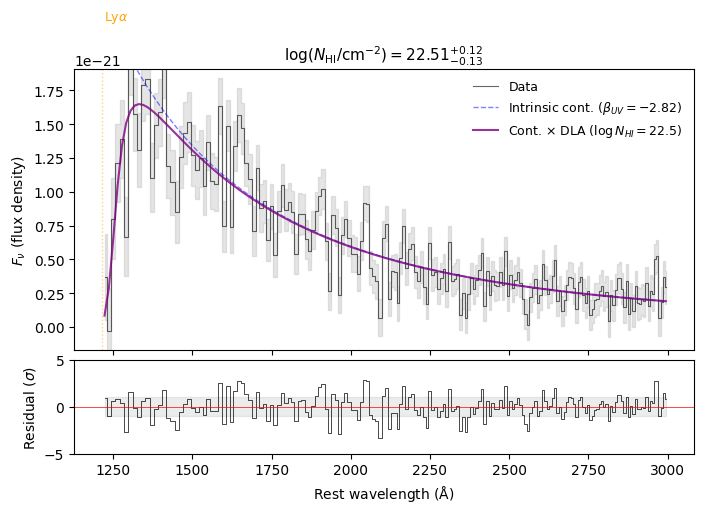

In [8]:
fig = result.plot(show_residuals=True)
plt.show()

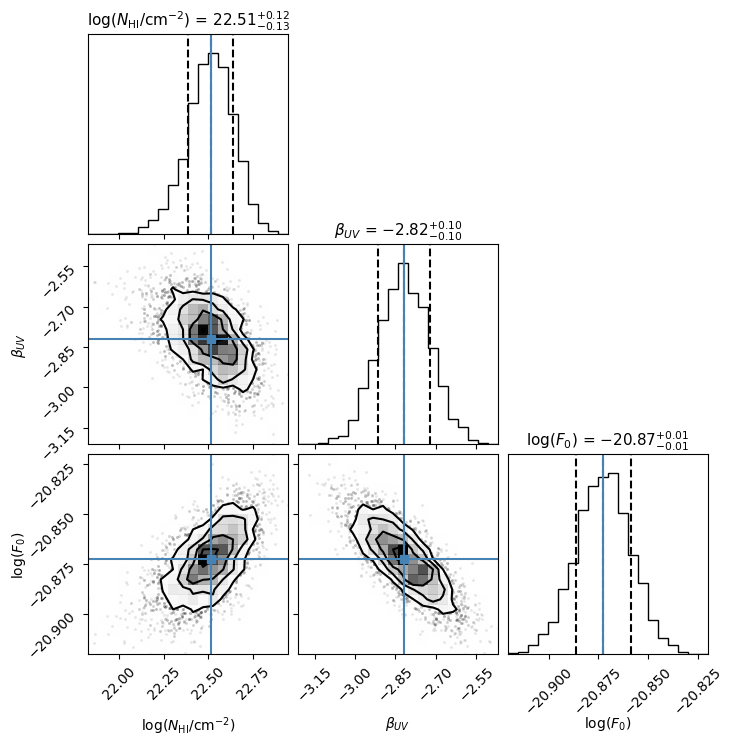

In [9]:
fig = result.corner(show_titles=True)
plt.show()